In [1]:
# SETUP & LIBRARIES
!pip install torch-geometric vtk pyvista pandas numpy matplotlib scikit-learn joblib tqdm gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.4/261.4 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 26.1 MB/s eta 0:00:00


In [2]:
# DOWNLOAD FULL REPOSITORY FROM DRIVE
import os
!gdown 1sNeYuIXATPekH2fRBD2Kl2EZGNOwF5KH -O repo.zip
!unzip -q -o repo.zip

# Change directory to ensure we are inside the repo
cartelle = [d for d in os.listdir() if os.path.isdir(d) and not d.startswith('.')]
for d in cartelle:
    if 'GAT' in d or 'surrogate' in d:
        os.chdir(d)
        break


Downloading...
From (original): https://drive.google.com/uc?id=1sNeYuIXATPekH2fRBD2Kl2EZGNOwF5KH
From (redirected): https://drive.google.com/uc?id=1sNeYuIXATPekH2fRBD2Kl2EZGNOwF5KH&confirm=t&uuid=e48ac6eb-d94f-45a5-9dfc-e41f207191d1
To: /content/repo.zip
100% 150M/150M [00:02<00:00, 66.9MB/s]


In [3]:
# GENERATE FULL GRAPHS (10K Nodes)
!python preprocess_run.py

Found 100 runs in CSV. Starting conversion to graphs...
  0% 0/100 [00:00<?, ?it/s]/content/GAT-AE-surrogate/preprocess_run.py:52: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([adj.row, adj.col], dtype=torch.long)
100% 100/100 [00:07<00:00, 12.99it/s]
Conversion complete! 100 graphs saved in data/processed_data


In [14]:
# SCOUT TRAINING
import os
import torch
import torch.nn.functional as F
from models.gnn_autoencoder import PhysicsScoutGATLite
from data.dataset import create_dataloaders
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('checkpoints', exist_ok=True)

print('Initializing SCOUT Dataloaders...')
train_loader_scout, val_loader_scout, _, _, _ = create_dataloaders(
    data_dir='data/processed_data',
    split_info_path='data/processed_data/split_info.json',
    batch_size=8
)

scout = PhysicsScoutGATLite(in_features=2, hidden_dim=32, heads=2).to(device)
optimizer = torch.optim.AdamW(scout.parameters(), lr=1e-3)
best_loss = float('inf')

for epoch in range(45):
    scout.train()
    for data in tqdm(train_loader_scout, leave=False, desc=f'Scout Ep {epoch+1}'):
        data = data.to(device)
        optimizer.zero_grad()
        loss = F.l1_loss(scout(data), data.y_local)
        loss.backward()
        optimizer.step()

    scout.eval()
    v_loss = sum(F.l1_loss(scout(d.to(device)), d.y_local).item() for d in val_loader_scout) / len(val_loader_scout)
    print(f'Epoch {epoch+1} | Scout Val Loss (L1): {v_loss:.4f}')
    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(scout.state_dict(), 'checkpoints/scout_model.pt')

Inizializzazione Dataloaders SCOUT...
Fitting scalers on 80 training graphs...


Fitting Scalers:   0%|          | 0/80 [00:00<?, ?it/s]

DataLoaders initialized. Train: 80, Val: 10, Test: 10


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Scout Ep 1:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoca 43 | Scout Val Loss (L1): 0.3736


Scout Ep 44:   0%|          | 0/10 [00:00<?, ?it/s]

Epoca 44 | Scout Val Loss (L1): 0.3774


Scout Ep 45:   0%|          | 0/10 [00:00<?, ?it/s]

Epoca 45 | Scout Val Loss (L1): 0.3690


In [15]:
# SMART SUBSAMPLING
!python preprocess_subsampled.py

Loading Scout model da checkpoints/scout_model.pt...
Generazione Grafi Subsampled: 100% 100/100 [00:08<00:00, 11.70it/s]
✅ Generazione dataset subsampled completata in data/refined_graphs!


In [16]:
# AUTOENCODER TRAINING
import torch
from train import train_autoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_autoencoder(
    data_dir='data/refined_graphs',
    split_info_path='data/refined_graphs/split_info.json',
    in_features=2,
    latent_dim=20,
    max_epochs=150,
    device=device
)

Initializing Dataloaders...
Fitting scalers on 80 training graphs...


Fitting Scalers:   0%|          | 0/80 [00:00<?, ?it/s]

DataLoaders initialized. Train: 80, Val: 10, Test: 10
Starting PUNITIVE Autoencoder Training on cuda...


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep 1:   0%|          | 0/7 [00:00<?, ?it/s]

...

Ep 102 | LR: 1.3e-04 | Train Loss: 0.0056 | Val Loss: 0.0136 


Ep 103:   0%|          | 0/7 [00:00<?, ?it/s]

Ep 103 | LR: 1.3e-04 | Train Loss: 0.0054 | Val Loss: 0.0141 


Ep 104:   0%|          | 0/7 [00:00<?, ?it/s]

Ep 104 | LR: 6.3e-05 | Train Loss: 0.0059 | Val Loss: 0.0141 
Early stopping triggered! Learning rate dropped below 1e-4.
Autoencoder Training Completed! Best model saved at checkpoints/pure_ae_model.pt


Recupero Scaler...
Fitting scalers on 80 training graphs...


Fitting Scalers:   0%|          | 0/80 [00:00<?, ?it/s]

DataLoaders initialized. Train: 80, Val: 10, Test: 10


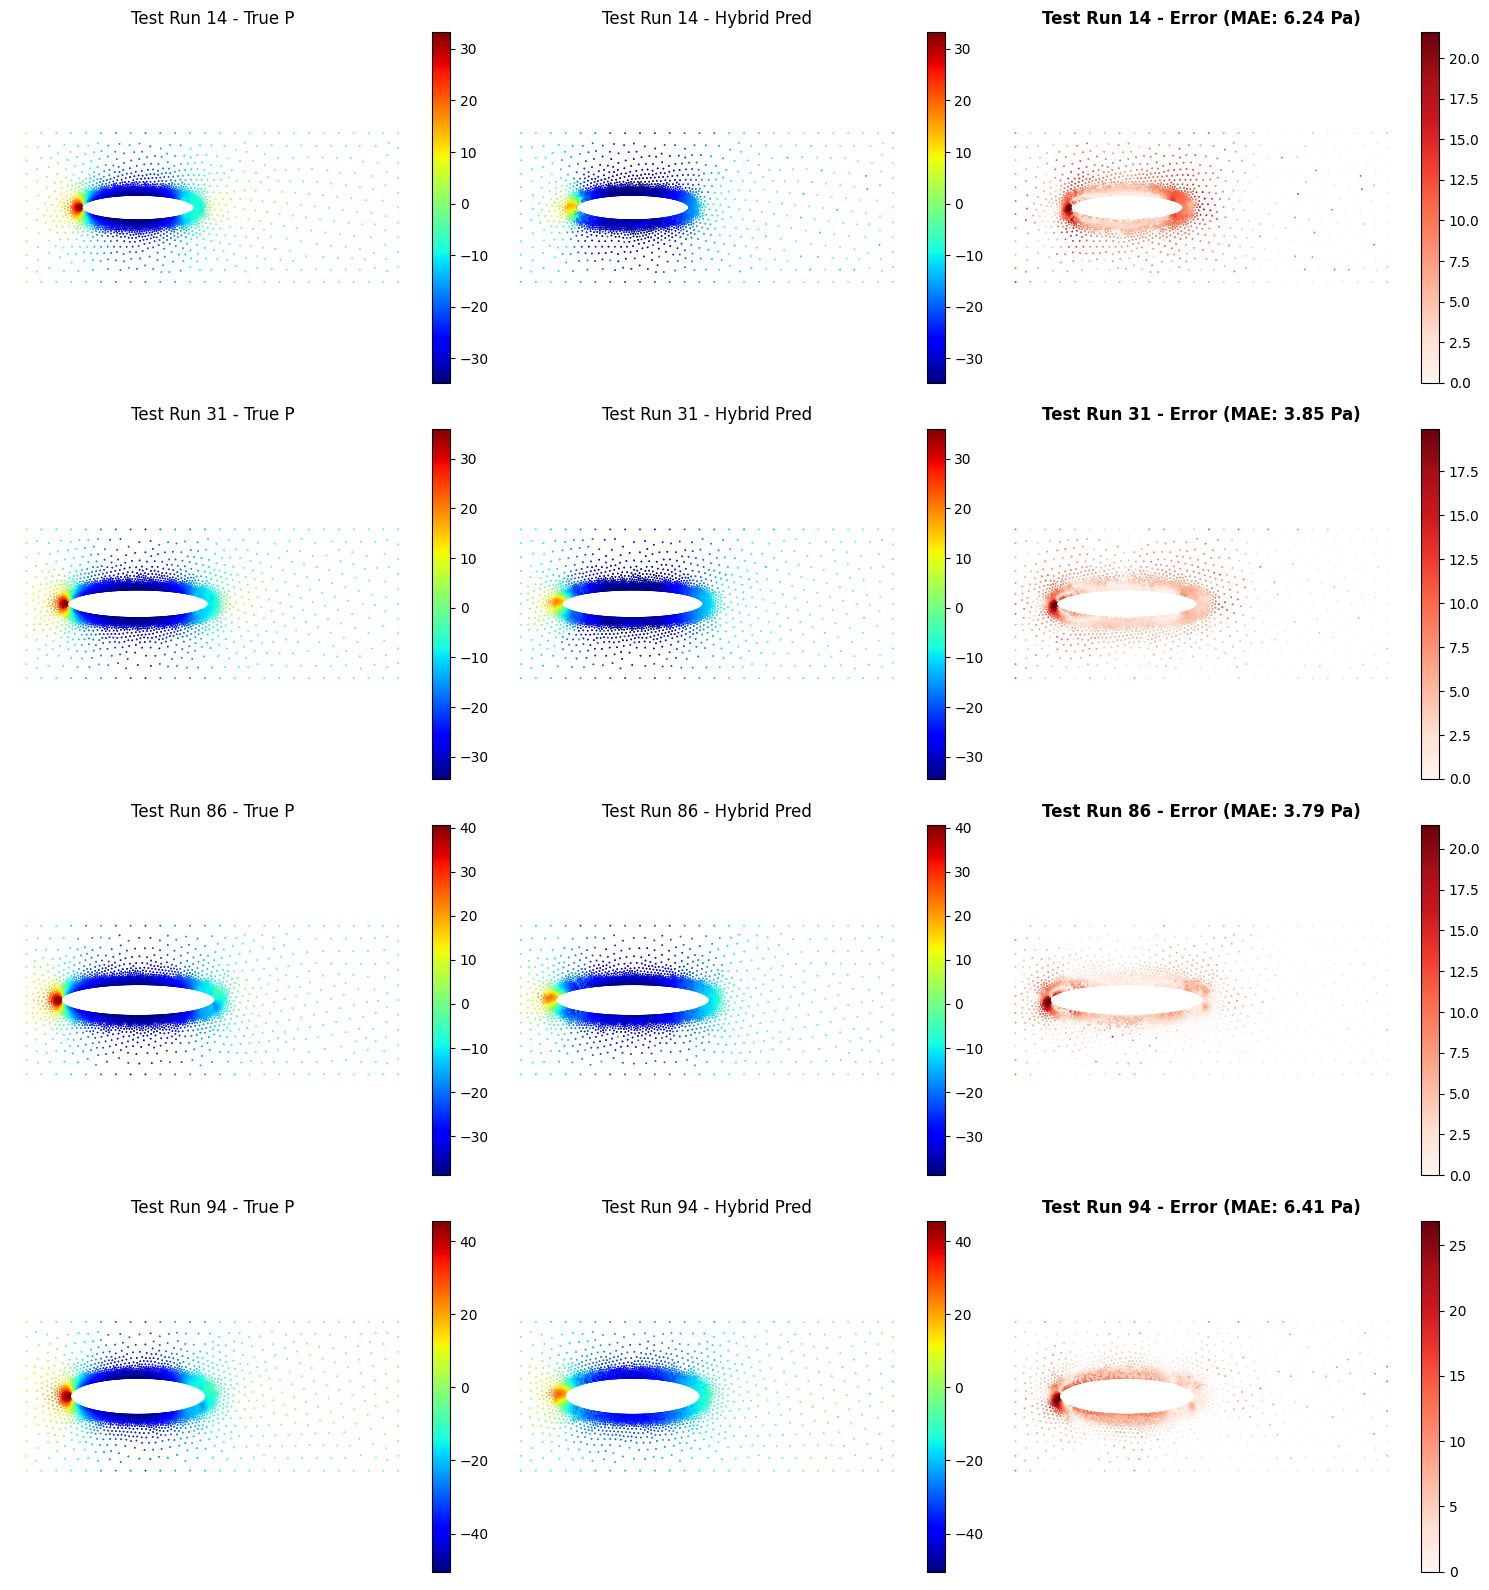

In [19]:
# HYBRID UPSAMPLING & PLOT
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from models.gnn_autoencoder import PressureAutoencoderGNN, PhysicsScoutGATLite
from data.dataset import create_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Recovering Scalers...')
_, _, _, scaler_p, _ = create_dataloaders(
    data_dir='data/processed_data',
    split_info_path='data/processed_data/split_info.json',
    batch_size=2, num_workers=0
)

scout = PhysicsScoutGATLite(in_features=2, hidden_dim=32, heads=2).to(device)
scout.load_state_dict(torch.load('checkpoints/scout_model.pt', weights_only=True, map_location=device))
scout.eval()

ae_model = PressureAutoencoderGNN(in_features=2, latent_dim=20, out_local=1, heads=2, hidden=64).to(device)
ae_model.load_state_dict(torch.load('checkpoints/pure_ae_model.pt', weights_only=True, map_location=device))
ae_model.eval()

with open('data/processed_data/split_info.json', 'r') as f:
    test_files_list = json.load(f)['test']

test_samples_info = []
for pt_file in test_files_list:
    d = torch.load(os.path.join('data/processed_data', pt_file), weights_only=False)
    test_samples_info.append((pt_file, d.y_global.item()))
test_samples_info.sort(key=lambda x: x[1])
n = len(test_samples_info)
test_files = [test_samples_info[0][0], test_samples_info[n // 3][0], test_samples_info[2 * (n // 3)][0], test_samples_info[-1][0]]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

with torch.no_grad():
    for i, pt_file in enumerate(test_files):
        d_full = torch.load(os.path.join('data/processed_data', pt_file), weights_only=False).to(device)
        if not hasattr(d_full, 'x') or d_full.x is None:
            d_full.x = d_full.pos
        p_scout_scaled = scout(d_full).cpu().squeeze().numpy()

        d_sub = torch.load(os.path.join('data/refined_graphs', pt_file), weights_only=False).to(device)
        if not hasattr(d_sub, 'x') or d_sub.x is None:
            d_sub.x = d_sub.pos
        p_ae_scaled = ae_model(d_sub).cpu().squeeze().numpy()

        p_hybrid_scaled = p_scout_scaled.copy()
        idx_sub = d_sub.original_idx.cpu().numpy()
        p_hybrid_scaled[idx_sub] = p_ae_scaled

        true_p = d_full.y_local.cpu().squeeze().numpy()
        pred_p = scaler_p.inverse_transform(p_hybrid_scaled.reshape(-1, 1)).flatten()

        vmin = np.percentile(true_p, 1)
        vmax = np.percentile(true_p, 99)
        true_p = np.clip(true_p, vmin, vmax)
        pred_p = np.clip(pred_p, vmin, vmax)

        error = np.abs(true_p - pred_p)
        mae = error.mean()

        pos = d_full.pos.cpu().numpy()
        x, y = pos[:, 0], pos[:, 1]

        run_id = pt_file.split('_')[1].split('.')[0]
        marker_size = 1.5

        sc0 = axes[i, 0].scatter(x, y, c=true_p, cmap='jet', s=marker_size, edgecolors='none', vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f'Test Run {run_id} - True P', fontsize=12)
        plt.colorbar(sc0, ax=axes[i, 0], fraction=0.046, pad=0.04)

        sc1 = axes[i, 1].scatter(x, y, c=pred_p, cmap='jet', s=marker_size, edgecolors='none', vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f'Test Run {run_id} - Hybrid Pred', fontsize=12)
        plt.colorbar(sc1, ax=axes[i, 1], fraction=0.046, pad=0.04)

        err_vmax = np.percentile(error, 99)
        sc2 = axes[i, 2].scatter(x, y, c=error, cmap='Reds', s=marker_size, edgecolors='none', vmin=0, vmax=err_vmax)
        axes[i, 2].set_title(f'Test Run {run_id} - Error (MAE: {mae:.2f} Pa)', fontsize=12, fontweight='bold')
        plt.colorbar(sc2, ax=axes[i, 2], fraction=0.046, pad=0.04)

        for ax in axes[i]:
            ax.set_aspect('equal', adjustable='datalim')
            ax.axis('off')

plt.tight_layout()
plt.savefig('checkpoints/hybrid_pressure_fields.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# LATENT SPACE EXTRACTION AND MLP TRAINING FOR Cd
import sys
# This clears the import cache per evitare brutti scherzi se hai modificato il file models
if 'models.gnn_autoencoder' in sys.modules:
    del sys.modules['models.gnn_autoencoder']

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm.auto import tqdm
from models.gnn_autoencoder import PressureAutoencoderGNN
from data.dataset import create_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Dataloaders on SUBSAMPLED data (da qui recuperiamo anche lo scaler_cd)
print("Initializing Dataloaders...")
train_loader_ae, val_loader_ae, test_loader_ae, _, scaler_cd = create_dataloaders(
    data_dir="data/refined_graphs",
    split_info_path="data/refined_graphs/split_info.json",
    batch_size=8, num_workers=0
)

# 2. Load the Trained Autoencoder'Autoencoder Addestrato
pretrained_ae = PressureAutoencoderGNN(in_features=2, latent_dim=20, out_local=1, heads=2, hidden=64).to(device)
pretrained_ae.load_state_dict(torch.load("checkpoints/pure_ae_model.pt", weights_only=True, map_location=device))
pretrained_ae.eval()

# 3. Function to extract the latent vector Z
def extract_latent_features(loader, model):
    X_list, y_list = [], []
    with torch.no_grad():
        for data in tqdm(loader, leave=False, desc="Estrazione Z"):
            data = data.to(device)
            z = model.encode(data)
            X_list.append(z.cpu())
            y_list.append(data.y_global.cpu())
    return torch.cat(X_list, dim=0), torch.cat(y_list, dim=0)

print("Latent Space Extraction in progress...")
X_train, y_train = extract_latent_features(train_loader_ae, pretrained_ae)
X_val, y_val = extract_latent_features(val_loader_ae, pretrained_ae)
X_test, y_test = extract_latent_features(test_loader_ae, pretrained_ae)

# 4. Define the lightweight MLP Predictor
class CdPredictor(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x)

mlp = CdPredictor(latent_dim=20).to(device)
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

train_loader_mlp = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader_mlp = DataLoader(TensorDataset(X_val, y_val), batch_size=32)

best_loss = float('inf')
print("MLP Training...")
for epoch in range(150):
    mlp.train()
    for xb, yb in train_loader_mlp:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_mlp.zero_grad()
        loss = F.mse_loss(mlp(xb), yb)
        loss.backward()
        optimizer_mlp.step()

    mlp.eval()
    v_loss = sum(F.mse_loss(mlp(xb.to(device)), yb.to(device)).item() for xb, yb in val_loader_mlp) / len(val_loader_mlp)

    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(mlp.state_dict(), "checkpoints/best_cd_mlp.pt")

print(f"✅ MLP Training completed. Best Val Loss: {best_loss:.4f}")

Inizializzazione Dataloaders...
Fitting scalers on 80 training graphs...


Fitting Scalers:   0%|          | 0/80 [00:00<?, ?it/s]

DataLoaders initialized. Train: 80, Val: 10, Test: 10
Estrazione Spazio Latente in corso...


Estrazione Z:   0%|          | 0/10 [00:00<?, ?it/s]

Estrazione Z:   0%|          | 0/2 [00:00<?, ?it/s]

Estrazione Z:   0%|          | 0/10 [00:00<?, ?it/s]

Addestramento MLP...
✅ Addestramento MLP completato. Best Val Loss: 0.0378


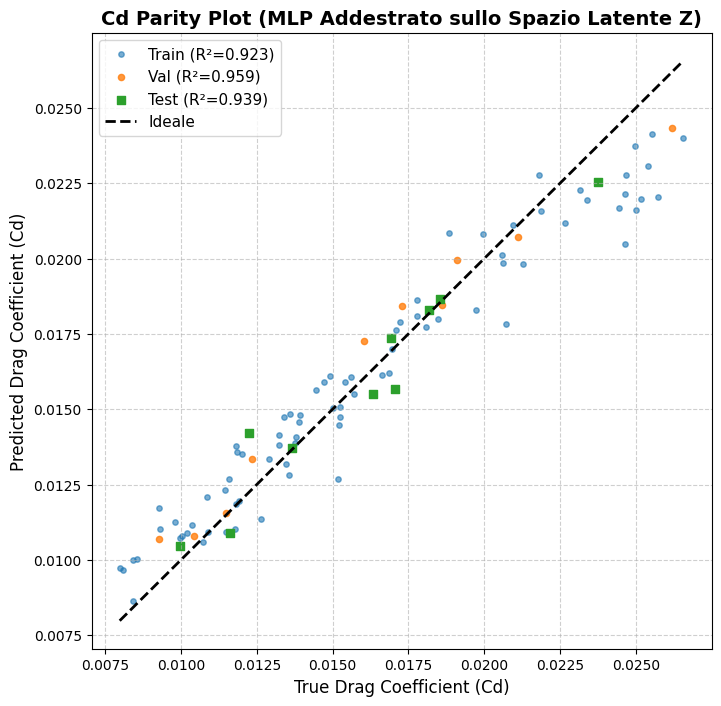

In [23]:
# AERODYNAMIC COEFFICIENT (Cd) PARITY PLOT
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Reload the best weights of the newly trained MLP'MLP appena addestrato
mlp.load_state_dict(torch.load("checkpoints/best_cd_mlp.pt", weights_only=True))
mlp.eval()

with torch.no_grad():
    # Make predictions (which are still normalized between -1 and 1) (che escono ancora in formato normalizzato tra -1 e 1)
    train_pred = mlp(X_train.to(device)).cpu().numpy()
    val_pred = mlp(X_val.to(device)).cpu().numpy()
    test_pred = mlp(X_test.to(device)).cpu().numpy()

    # DE-NORMALIZATION (Use scaler_cd to return to true physical Cd values!) (Usiamo lo scaler_cd per tornare ai veri valori fisici di Cd!)
    train_pred = scaler_cd.inverse_transform(train_pred)
    val_pred = scaler_cd.inverse_transform(val_pred)
    test_pred = scaler_cd.inverse_transform(test_pred)

    train_true = scaler_cd.inverse_transform(y_train.numpy())
    val_true = scaler_cd.inverse_transform(y_val.numpy())
    test_true = scaler_cd.inverse_transform(y_test.numpy())

# Calculate R2 metrics
r2_train = r2_score(train_true, train_pred)
r2_val = r2_score(val_true, val_pred)
r2_test = r2_score(test_true, test_pred)

plt.figure(figsize=(8, 8))
plt.scatter(train_true, train_pred, label=f'Train (R²={r2_train:.3f})', alpha=0.6, s=15)
plt.scatter(val_true, val_pred, label=f'Val (R²={r2_val:.3f})', alpha=0.8, s=20)
plt.scatter(test_true, test_pred, label=f'Test (R²={r2_test:.3f})', alpha=1.0, s=30, marker='s')

# Draw the Ideal line (y = x)
min_val = min(train_true.min(), train_pred.min())
max_val = max(train_true.max(), train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal', linewidth=2)

plt.xlabel("True Drag Coefficient (Cd)", fontsize=12)
plt.ylabel("Predicted Drag Coefficient (Cd)", fontsize=12)
plt.title("Cd Parity Plot (MLP Trained on Latent Space Z)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("checkpoints/cd_parity_plot.png", dpi=300)
plt.show()